In [1]:
# Standard libraries
import os
from typing import List, Tuple

# Data manipulation and numerical computation
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, mutual_info_regression, f_classif, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Other utilities
from scipy.stats import randint, uniform
import joblib

In [2]:
# Standard libraries
import os

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [3]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [4]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
cleandf = pd.read_parquet(os.path.join(path, "03_CLEAN_COMPLETE_DF_02.parquet"))
cleandf

,TotalAbundance_SamplingOperation,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,CodeSite_SamplingOperations_y,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1176,Mean180Days_1177,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180Days_1

In [5]:
# lets drop the rows that have NaN in IBD
TRAIN = cleandf[cleandf['IBD'].notna()]
y = TRAIN['IBD']
X = TRAIN.drop(columns=['IBD','IBD_EQR','IBD_EQR_Status'])
target_cols = ['IBD','IBD_EQR','IBD_EQR_Status']  # pon todos tus objetivos aquí
X = X.drop(columns=[c for c in target_cols if c in X.columns], errors='ignore')


In [6]:
TEST = cleandf[cleandf['IBD'].isna()]
TEST = TEST.drop(columns=['IBD','IBD_EQR','IBD_EQR_Status'])


In [7]:

num_cols_X = X.select_dtypes(include=['number']).columns
cat_cols   = X.columns.difference(num_cols_X)

# (opcional) sanity checks
missing_in_X = [c for c in cat_cols if c not in X.columns]
assert not missing_in_X, f"Hay columnas en cat_cols que no están en X: {missing_in_X}"

print(f"num_cols_X: {len(num_cols_X)} | cat_cols: {len(cat_cols)}")


num_cols_X: 590 | cat_cols: 30


In [8]:
def build_robust_corr(
    df: pd.DataFrame,
    num_cols=None,
    method: str = "pearson",          # "pearson" o "spearman"
    min_pairs: int = 50,              # mínimo de observaciones conjuntas para aceptar una r
    min_pair_coverage: float = 0.30,  # o cobertura mínima (fracción sobre N filas)
    drop_almost_constant: bool = True,
    const_std_tol: float = 1e-12,     # tolerancia de "casi constante"
    min_col_coverage: float = 0.50    # cobertura mínima por columna (fracción no nulos)
):
    """
    Retorna:
        corr        -> DataFrame de correlaciones (NaN donde no hay evidencia suficiente)
        pair_counts -> DataFrame con el número de pares válidos por correlación
        pair_cov    -> DataFrame con la cobertura de pares válidos (sobre N filas)
        kept_cols   -> lista de columnas numéricas consideradas
        dropped     -> dict con listas de columnas descartadas y el motivo
    """
    # 0) Columnas numéricas
    if num_cols is None:
        num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    num_df = df[num_cols].copy()

    # 1) Reemplaza inf/-inf por NaN
    num_df = num_df.replace([np.inf, -np.inf], np.nan)

    N = len(num_df)

    dropped = {"low_coverage": [], "constant": []}

    # 2) Elimina columnas con cobertura muy baja
    col_cov = num_df.notna().mean(axis=0)  # fracción de no-nulos por columna
    low_cov_cols = col_cov[col_cov < min_col_coverage].index.tolist()
    if low_cov_cols:
        num_df = num_df.drop(columns=low_cov_cols)
        dropped["low_coverage"].extend(low_cov_cols)

    # 3) Elimina columnas constantes o casi constantes (opcional)
    if drop_almost_constant and num_df.shape[1] > 0:
        # std con NaN-robusto (omite NaN); constante si std≈0 o nunique<=1
        stds = num_df.std(skipna=True)
        nunq = num_df.nunique(dropna=True)
        const_cols = stds[stds <= const_std_tol].index.tolist()
        const_cols += nunq[nunq <= 1].index.tolist()
        const_cols = sorted(set(const_cols))
        if const_cols:
            num_df = num_df.drop(columns=const_cols)
            dropped["constant"].extend(const_cols)

    kept_cols = num_df.columns.tolist()
    if len(kept_cols) == 0:
        # No hay columnas para correlacionar
        corr = pd.DataFrame()
        pair_counts = pd.DataFrame()
        pair_cov = pd.DataFrame()
        return corr, pair_counts, pair_cov, kept_cols, dropped

    # 4) Matriz de conteo de pares válidos (observaciones conjuntas no nulas)
    valid = num_df.notna().astype(int)
    pair_counts = pd.DataFrame(
        valid.T.values @ valid.values,
        index=kept_cols,
        columns=kept_cols
    )
    pair_cov = pair_counts / float(N)

    # 5) Matriz de correlación (pairwise-complete por defecto en pandas)
    corr = num_df.corr(method=method)

    # 6) Enmascara correlaciones con evidencia insuficiente
    #    (por debajo de min_pairs o min_pair_coverage) -> NaN
    low_evidence = (pair_counts < min_pairs) | (pair_cov < min_pair_coverage)
    corr = corr.mask(low_evidence)

    return corr, pair_counts, pair_cov, kept_cols, dropped




In [9]:


corr, pair_counts, pair_cov, kept_cols, dropped = build_robust_corr(
    X,
    num_cols=X.select_dtypes(include=['number']).columns,
    method="spearman",
    min_pairs=5000,
    min_pair_coverage=0.60,
    drop_almost_constant=True,
    const_std_tol=1e-12,
    min_col_coverage=0.70
)

print(f"Columnas numéricas consideradas: {len(kept_cols)}")
print("Descartadas por baja cobertura:", len(dropped['low_coverage']))
print("Descartadas por constancia:", len(dropped['constant']))



Columnas numéricas consideradas: 53
Descartadas por baja cobertura: 537
Descartadas por constancia: 0


In [10]:
# 2) Identify column types
kept_num_cols = kept_cols


In [11]:
kept_num_cols

['TotalAbundance_SamplingOperation',
 'Achmi02',
 'Amppe02',
 'Coceu01',
 'Navcr09',
 'Nitdi04',
 'Selni01',
 'Longitude_Lambert93',
 'Latitude_Lambert93',
 'HERlvl1Code',
 'HERlvl2Code',
 'Altitude',
 'CodeSite_SamplingOperations_y',
 'Mean180Days_1295',
 'Mean180Days_1302',
 'Mean180Days_1305',
 'Mean180Days_1311',
 'Mean180Days_1312',
 'Mean180Days_1313',
 'Mean180Days_1319',
 'Mean180Days_1335',
 'Mean180Days_1339',
 'Mean180Days_1340',
 'Mean180Days_1350',
 'Mean180Days_1433',
 'Mean180Days_1841',
 'Mean1Y_1295',
 'Mean1Y_1302',
 'Mean1Y_1305',
 'Mean1Y_1311',
 'Mean1Y_1312',
 'Mean1Y_1313',
 'Mean1Y_1319',
 'Mean1Y_1335',
 'Mean1Y_1339',
 'Mean1Y_1340',
 'Mean1Y_1350',
 'Mean1Y_1433',
 'Mean1Y_1841',
 'Mean90Days_1295',
 'Mean90Days_1302',
 'Mean90Days_1305',
 'Mean90Days_1311',
 'Mean90Days_1312',
 'Mean90Days_1313',
 'Mean90Days_1319',
 'Mean90Days_1335',
 'Mean90Days_1339',
 'Mean90Days_1340',
 'Mean90Days_1350',
 'Mean90Days_1433',
 'Mean90Days_1841',
 'Uncommon_Taxons']

In [12]:

MIN_COL_COVERAGE = 0.70     # cobertura mínima por columna
DOMINANCE_THR    = 0.95     # si la categoría más frecuente > 95%, considerar casi-constante
MAX_LEVELS       = 200      # no calcular asociaciones si niveles > este umbral
MIN_PAIR_COVER   = 0.60     # cobertura mínima conjunta para calcular V
MIN_PAIR_COUNT   = 5000     # mínimo de observaciones conjuntas
CRAMER_THR       = 0.85     # umbral para considerar “altamente asociadas” (redundantes)


def eta_squared_by_category(y: pd.Series, x: pd.Series) -> float:
    """
    η² = SSB / SST para target continuo 'y' y categórica 'x'.
    Ignora NaN en cualquiera de las dos.
    """
    df = pd.DataFrame({'y': y, 'x': x}).dropna()
    if df.empty:
        return np.nan
    overall_mean = df['y'].mean()
    # SSB: suma de n_g * (mean_g - overall_mean)^2
    grp = df.groupby('x')['y'].agg(['count', 'mean'])
    ssb = ((grp['count'] * (grp['mean'] - overall_mean) ** 2)).sum()
    sst = ((df['y'] - overall_mean) ** 2).sum()
    if sst <= 0:
        return np.nan
    return float(ssb / sst)

def cramers_v_corrected(a: pd.Series, b: pd.Series) -> float:
    """
    Cramer's V corregido por sesgo (Bergsma & Wicher).
    Ignora NaN, aplica corrección y devuelve V in [0,1].
    Devuelve np.nan si no hay suficiente evidencia.
    """
    data = pd.DataFrame({'a': a, 'b': b}).dropna()
    n = len(data)
    if n == 0:
        return np.nan
    # Tabla de contingencia
    tbl = pd.crosstab(data['a'], data['b'])
    r, k = tbl.shape
    # Rechaza si la tabla es degenerada
    if r < 2 or k < 2:
        return np.nan
    # Chi-cuadrado
    chi2, _, _, _ = chi2_contingency(tbl, correction=False)
    phi2 = chi2 / n
    # Corrección por sesgo
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = max(min(rcorr - 1, kcorr - 1), 1e-12)  # evitar /0
    v = np.sqrt(phi2corr / denom)
    # Clip numérico
    return float(np.clip(v, 0.0, 1.0))

def connected_components_from_adj(adj: pd.DataFrame) -> list[list[str]]:
    """
    Componentes conexas en un grafo no dirigido dado por una matriz de adyacencia booleana (DataFrame).
    """
    nodes = adj.index.tolist()
    A = adj.values.astype(bool)
    visited = set()
    comps = []
    for i, v in enumerate(nodes):
        if v in visited:
            continue
        stack = [i]
        comp_idx = []
        while stack:
            u = stack.pop()
            if u in comp_idx:
                continue
            comp_idx.append(u)
            neigh = np.where(A[u])[0]
            for w in neigh:
                if w not in comp_idx:
                    stack.append(w)
        for j in comp_idx:
            visited.add(nodes[j])
        comps.append([nodes[j] for j in comp_idx])
    return comps


In [13]:

cat_df = X[cat_cols].copy()
cat_df = cat_df.replace([np.inf, -np.inf], np.nan)

N = len(cat_df)


In [14]:

# Métricas por columna
summary_rows = []
for c in cat_df.columns:
    s = cat_df[c]
    cov = s.notna().mean()
    nun = s.nunique(dropna=True)
    dom = (s.value_counts(dropna=True, normalize=True).iloc[0]
           if nun > 0 else np.nan)
    summary_rows.append({
        'col': c,
        'coverage': cov,
        'n_levels': nun,
        'dominance': dom
    })

cat_summary = pd.DataFrame(summary_rows).sort_values('col').reset_index(drop=True)

# Filtros previos
low_cov_cols = cat_summary.loc[cat_summary['coverage'] < MIN_COL_COVERAGE, 'col'].tolist()
dominant_cols = cat_summary.loc[cat_summary['dominance'] >= DOMINANCE_THR, 'col'].tolist()
one_level_cols = cat_summary.loc[cat_summary['n_levels'] <= 1, 'col'].tolist()

# Mantén candidatas razonables para asociación
candidate_cols = cat_summary.loc[
    (cat_summary['coverage'] >= MIN_COL_COVERAGE) &
    (cat_summary['n_levels'] > 1)
, 'col'].tolist()

print(f"Categóricas totales: {len(cat_cols)}")
print(f"Descartadas por baja cobertura (<{MIN_COL_COVERAGE:.0%}): {len(low_cov_cols)}")
print(f"Descartadas por casi-constantes (dominancia ≥{DOMINANCE_THR:.0%}): {len(dominant_cols)}")
print(f"Descartadas por 1 nivel: {len(one_level_cols)}")
print(f"Candidatas para asociación: {len(candidate_cols)}")

# =========================
# 2) η² (cada categórica vs IBD)
# =========================
eta2_map = {}
for c in candidate_cols:
    eta2_map[c] = eta_squared_by_category(y, cat_df[c])

eta2 = pd.Series(eta2_map, name='eta2').sort_values(ascending=False)

# =========================
# 3) Cramer’s V entre pares categóricos (con filtros)
# =========================
# Limitamos a columnas con #niveles <= MAX_LEVELS (para que no explote la tabla)
levels_map = cat_df[candidate_cols].nunique(dropna=True).to_dict()
small_card_cols = [c for c in candidate_cols if levels_map.get(c, 0) <= MAX_LEVELS]

# Prealoca estructuras
V_index = small_card_cols
V = pd.DataFrame(index=V_index, columns=V_index, dtype=float)

# Matriz de conteo conjunto válido (para cobertura de pares)
notna_mat = cat_df[small_card_cols].notna().astype(int)
pair_counts = pd.DataFrame(notna_mat.T.values @ notna_mat.values, index=V_index, columns=V_index)
pair_cov = pair_counts / float(N)

# Calcular V sólo si ambos pasan filtros de niveles y el par tiene suficiente evidencia
for i, c1 in enumerate(small_card_cols):
    V.loc[c1, c1] = 1.0
    for j in range(i+1, len(small_card_cols)):
        c2 = small_card_cols[j]
        # filtros de evidencia
        if (pair_counts.loc[c1, c2] < MIN_PAIR_COUNT) or (pair_cov.loc[c1, c2] < MIN_PAIR_COVER):
            v = np.nan
        else:
            v = cramers_v_corrected(cat_df[c1], cat_df[c2])
        V.loc[c1, c2] = v
        V.loc[c2, c1] = v

# =========================
# 4) Redundancia por grupos (V alto)
# =========================
# Adyacencia booleana: V >= CRAMER_THR (ignorando NaN)
adj = (V >= CRAMER_THR)
adj = adj.fillna(False)
np.fill_diagonal(adj.values, False)

# Componentes conexas (grupos de columnas redundantes)
components = connected_components_from_adj(adj)

# Selección dentro de cada grupo por mayor η² con IBD
keep, drop = set(), set()
for comp in components:
    if len(comp) == 1:
        keep.add(comp[0])
        continue
    # η² de las variables del grupo
    best = max(comp, key=lambda c: (eta2_map.get(c, np.nan), -levels_map.get(c, 10**9)))
    # Nota: el tie-break secundario favorece menor cardinalidad si η² empata/NaN
    keep.add(best)
    drop.update([c for c in comp if c != best])

# Agrega columnas candidatas que no están en ningún grupo (sin edges)
all_in_groups = set(sum(components, []))
isolated = set(small_card_cols) - all_in_groups
keep.update(isolated)

# =========================
# 5) Reportes
# =========================
redundant_pairs = []
for i in range(len(V_index)):
    for j in range(i+1, len(V_index)):
        c1, c2 = V_index[i], V_index[j]
        v = V.loc[c1, c2]
        if pd.notna(v) and v >= CRAMER_THR:
            redundant_pairs.append((c1, c2, float(v)))

redundant_pairs = sorted(redundant_pairs, key=lambda t: t[2], reverse=True)

summary = cat_summary.set_index('col').reindex(candidate_cols)
summary['eta2'] = [eta2_map.get(c, np.nan) for c in candidate_cols]
summary['n_levels'] = summary['n_levels'].astype('Int64')
summary = summary.sort_values('eta2', ascending=False)

print("\n=== Resumen de categóricas candidatas ===")
display(summary.head(20))

print(f"\nPares redundantes (Cramer's V ≥ {CRAMER_THR}): {len(redundant_pairs)}")
if redundant_pairs:
    display(pd.DataFrame(redundant_pairs, columns=['col_1','col_2','cramers_v']).head(30))

print(f"\nConservar: {len(keep)}  |  Eliminar por redundancia: {len(drop)}")
# Listas finales útiles:
cat_keep = sorted(list(keep))
cat_drop = sorted(list(drop))

# Si quisieras la lista total descartada (baja cobertura, dominancia, 1 nivel, alta redundancia):
discard_all = sorted(set(low_cov_cols + dominant_cols + one_level_cols + cat_drop))

print(f"Total descartadas (cobertura/dominancia/1nivel/redundancia): {len(discard_all)}")


Categóricas totales: 30
Descartadas por baja cobertura (<70%): 9
Descartadas por casi-constantes (dominancia ≥95%): 5
Descartadas por 1 nivel: 0
Candidatas para asociación: 21

=== Resumen de categóricas candidatas ===


,coverage,n_levels,dominance,eta2
col,,,,
Phosphorouscompounds_Status1Y,0.987697,5,0.507111,0.347355
Phosphorouscompounds_Status90D,0.953383,5,0.496136,0.331498
Phosphorouscompounds_Status180D,0.969335,5,0.492494,0.330639
Nitrogencompounds_Status180D,0.969198,5,0.582319,0.299950
Nitrogencompounds_Status1Y,0.987927,5,0.575345,0.293771
Nitrogencompounds_Status90D,0.953200,5,0.595223,0.268228
CodeDepartement,1.000000,94,0.029402,0.262708
HERlvl1Name,1.000000,22,0.209695,0.259138
Nitrates_Status1Y,0.988501,5,0.394711,0.173241



Pares redundantes (Cramer's V ≥ 0.85): 1


,col_1,col_2,cramers_v
0,CodeDepartement,Watershed,0.953094



Conservar: 20  |  Eliminar por redundancia: 1
Total descartadas (cobertura/dominancia/1nivel/redundancia): 12


In [15]:
kept_cat_cols = cat_keep

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
import pandas as pd

# --- Asegúrate que estas listas ya vengan de tus pasos de depuración ---
# kept_num_cols = [...]   # numéricas depuradas (no redundantes)
# kept_cat_cols = [...]   # categóricas depuradas (no redundantes)


# 1) Preprocesamiento
pre = ColumnTransformer(
    transformers=[
        # Numéricas: imputación por mediana (RF no necesita escalar)
        ('num', Pipeline(steps=[
            ('imp', SimpleImputer(strategy='median')),
        ]), kept_num_cols),

        # Categóricas: imputación + OHE
        ('cat', Pipeline(steps=[
            ('imp', SimpleImputer(strategy='constant', fill_value='None')),
            # Sugerencias:
            # - handle_unknown='ignore' para robustez en inferencia
            # - drop='if_binary' para no generar dos dummies en binarias
            # - min_frequency para agrupar categorías raras (si tu versión de sklearn lo tiene)
            ('ohe', OneHotEncoder(handle_unknown='ignore', drop='if_binary'
                                  # , min_frequency=0.01   # descomenta si tu sklearn >=1.1
                                  ))
        ]), kept_cat_cols),
    ],
    remainder='drop',
    sparse_threshold=1.0  # mantiene salida esparsa; RF la soporta
)

# 2) Modelo
rf = RandomForestRegressor(
    n_estimators=100,
    #max_depth=18,
    #max_features=0.25,     
    #min_samples_leaf=6,     
    #n_jobs=-1,
    random_state=42,
    #min_samples_split=12,
    #oob_score=False          
)

# 3) Pipeline completo
clf = Pipeline(steps=[
    ('pre', pre),
    ('model', rf)
], memory=None)  # puedes usar joblib.Memory para cachear si quieres



In [17]:
from sklearn.model_selection import train_test_split

# 1) Arma X e y solo con tus 75 regresores finales
X_base = X[kept_num_cols + kept_cat_cols].copy()
y_base = TRAIN.loc[X_base.index, 'IBD'].copy()

# 2) Split 80/20
X_train, X_valid, y_train, y_valid = train_test_split(
    X_base, y_base, test_size=0.20, random_state=42
)


In [ ]:


# 3) Entrena y evalúa (usa tu pipeline clf definido antes)
clf.fit(X_train, y_train)
print("R2 train:", clf.score(X_train, y_train))
print("R2 valid:", clf.score(X_valid, y_valid))


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred = clf.predict(X_valid)
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("RMSE:", mean_squared_error(y_valid, y_pred))


MAE: 0.9754703784550521
RMSE: 2.0285281436841


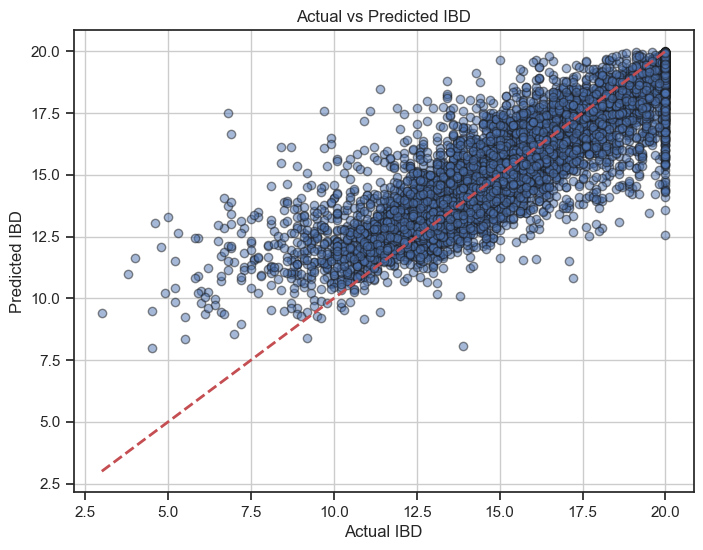

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_valid, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.xlabel('Actual IBD')
plt.ylabel('Predicted IBD')
plt.title('Actual vs Predicted IBD')
plt.grid(True)
plt.show()

In [ ]:
from catboost import CatBoostRegressor, Pool
import numpy as np
import pandas as pd

# 1) Build the dataframe for CatBoost (NO OHE here)
cols_for_cb = kept_num_cols + kept_cat_cols
X_cb = X[cols_for_cb].copy()
y_cb = TRAIN.loc[X_cb.index, 'IBD'].copy()

# Ensure categorical dtypes are object/string (CatBoost will detect them)
for c in kept_cat_cols:
    X_cb[c] = X_cb[c].astype('object')

# 2) Train/valid split (use the same split you used before if you want fair comparison)
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X_cb, y_cb, test_size=0.20, random_state=42
)

# 3) Indices of categorical columns (positions in X_train)
cat_idx = [X_train.columns.get_loc(c) for c in kept_cat_cols]

# 4) CatBoost pools
train_pool = Pool(X_train, y_train, cat_features=cat_idx)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_idx)

# 5) Model (solid baseline)
cb = CatBoostRegressor(
    loss_function='RMSE',
    depth=8,
    learning_rate=0.05,
    iterations=2000,            # with early stopping it won’t overfit
    l2_leaf_reg=6,
    subsample=0.8,
    random_seed=42,
    verbose=False
)

# 6) Fit with early stopping on the valid set
cb.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=100)

# 7) Evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
y_pred = cb.predict(X_valid)
print("R2 valid:", r2_score(y_valid, y_pred))
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("RMSE:", mean_squared_error(y_valid, y_pred, squared=False))


TypeError: must be real number, not NoneType